# 9.4

## c)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(seed=42)

In [2]:
df = pd.read_csv("../../Datasets_from_the_book/salmon.dat", sep="\s+", dtype=np.float64)
categories = df.columns.tolist()
data = df.to_numpy()

In [3]:
# The estimator for the stabilization point R = S

def theta_hat(beta1, beta2):
    return (1 - beta2)/beta1

In [5]:
years = data[:,0]
R = data[:,1]
S = data[:,2]

r = 1/R
s = 1/S
r = r.reshape(-1,1)
s = s.reshape(-1,1)

model = LinearRegression(fit_intercept=True).fit(X=s, y=r)
beta2_orig = model.coef_.item()
beta1_orig = model.intercept_.item()

point_est_theta_hat = theta_hat(beta1_orig, beta2_orig)
print(point_est_theta_hat)

150.0976343009786


In [7]:
rng = np.random.default_rng(seed=42)

n_bootstraps = 1000
n_indv_samples = len(r)
s_r_pairs = np.concatenate((s,r), axis=1)

# Preparation for the residual bootstrap, we first calculate the residuals on the original sample
model = LinearRegression(fit_intercept=True).fit(X=s, y=r)
prediction_orig = model.predict(s)
residuals_orig = r - prediction_orig

bootstraps_res_bias_corrected_estimates = np.zeros([n_bootstraps])
bootstraps_pairs_bias_corrected_estimates = np.zeros([n_bootstraps])

n_nested_bootstraps = 100

for i in range(n_bootstraps):
    # Residual bootstrap
    bootstrap_residuals = rng.choice(residuals_orig, n_indv_samples, replace=True)
    bootstrap_res_y = prediction_orig + bootstrap_residuals    
    model_bootstrap_res = LinearRegression(fit_intercept=True).fit(X=s, y=bootstrap_res_y)
    prediction_bootstrap = model_bootstrap_res.predict(s)
    res_beta1 = model_bootstrap_res.intercept_.item()
    res_beta2 = model_bootstrap_res.coef_.item()
    bootstrap_res_estimate = theta_hat(res_beta1, res_beta2)

    # Pair bootstrap
    bootstrap_pairs = rng.choice(s_r_pairs, n_indv_samples, replace=True)
    model_bootstrap_pair = LinearRegression(fit_intercept=True).fit(X=bootstrap_pairs[:,0].reshape(-1,1), y=bootstrap_pairs[:,1].reshape(-1,1))
    pairs_beta1 = model_bootstrap_pair.intercept_.item()
    pairs_beta2 = model_bootstrap_pair.coef_.item()
    bootstrap_pairs_estimate = theta_hat(pairs_beta1, pairs_beta2)

    nested_res_estimates = np.zeros([n_nested_bootstraps])
    nested_pairs_estimates = np.zeros([n_nested_bootstraps])
    # The nested bootstrap
    for j in range(n_nested_bootstraps):
        # Nested bootstrap residuals
        nested_res = rng.choice(bootstrap_residuals, n_indv_samples, replace=True)
        nested_res_y = prediction_bootstrap + nested_res
        model_nested_res = LinearRegression(fit_intercept=True).fit(X=s, y=nested_res_y)
        nested_res_beta1 = model_nested_res.intercept_.item()
        nested_res_beta2 = model_nested_res.coef_.item()
        nested_res_estimates[j] = theta_hat(nested_res_beta1, nested_res_beta2)

        # Nested bootstrap pairs
        nested_pairs = rng.choice(bootstrap_pairs, n_indv_samples, replace=True)
        nested_pairs_s = nested_pairs[:,0].reshape(-1,1)
        nested_pairs_r = nested_pairs[:,1].reshape(-1,1)
        model_nested_pairs = LinearRegression(fit_intercept=True).fit(X=nested_pairs_s, y=nested_pairs_r)
        nested_pairs_beta1 = model_nested_pairs.intercept_.item()
        nested_pairs_beta2 = model_nested_pairs.coef_.item()
        nested_pairs_estimates[j] = theta_hat(nested_pairs_beta1, nested_pairs_beta2)

        if i % 100 == 0 and j % 10 == 0:
            print(i,j)

    bias_res_estimate = np.mean(nested_res_estimates) - bootstrap_res_estimate
    bias_res_corrected_estimate = bootstrap_res_estimate - bias_res_estimate
    bootstraps_res_bias_corrected_estimates[i] = bias_res_corrected_estimate

    bias_pairs_estimate = np.mean(nested_pairs_estimates) - bootstrap_pairs_estimate
    bias_pairs_corrected_estimate = bootstrap_pairs_estimate - bias_pairs_estimate
    bootstraps_pairs_bias_corrected_estimates[i] = bias_pairs_corrected_estimate

0 0
0 10
0 20
0 30
0 40
0 50
0 60
0 70


KeyboardInterrupt: 

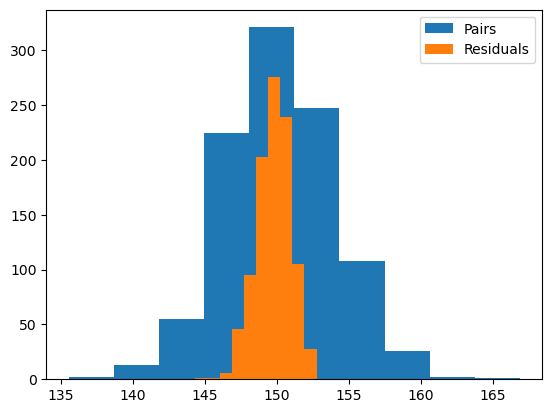

In [120]:
plt.hist(bootstraps_pairs_bias_corrected_estimates, label="Pairs")
plt.hist(bootstraps_res_bias_corrected_estimates, label="Residuals")
plt.legend()
plt.show()

In [113]:
ci95_res_corrected = np.percentile(bootstraps_res_bias_corrected_estimates, [2.5, 97.5])
ci95_pairs_corrected = np.percentile(bootstraps_pairs_bias_corrected_estimates, [2.5, 97.5])

print(ci95_res_corrected)
print(ci95_pairs_corrected)

[147.31788942 151.95874436]
[142.4794099  157.55797917]


### With prepivoting 

In [ ]:
rng = np.random.default_rng(seed=42)

n_bootstraps = 1000
n_indv_samples = len(r)
s_r_pairs = np.concatenate((s,r), axis=1)

# Preparation for the residual bootstrap, we first calculate the residuals on the original sample
model = LinearRegression(fit_intercept=True).fit(X=s, y=r)
prediction_orig = model.predict(s)
residuals_orig = r - prediction_orig

bootstraps_res_bias_corrected_estimates = np.zeros([n_bootstraps])
bootstraps_pairs_bias_corrected_estimates = np.zeros([n_bootstraps])

bootstraps_res_p_values = np.zeros([n_bootstraps])
bootstraps_pairs_p_values = np.zeros([n_bootstraps])

n_nested_bootstraps = 100

for i in range(n_bootstraps):
    # Residual bootstrap
    bootstrap_residuals = rng.choice(residuals_orig, n_indv_samples, replace=True)
    bootstrap_res_y = prediction_orig + bootstrap_residuals    
    model_bootstrap_res = LinearRegression(fit_intercept=True).fit(X=s, y=bootstrap_res_y)
    prediction_bootstrap = model_bootstrap_res.predict(s)
    res_beta1 = model_bootstrap_res.intercept_.item()
    res_beta2 = model_bootstrap_res.coef_.item()
    bootstrap_res_estimate = theta_hat(res_beta1, res_beta2)

    # Pair bootstrap
    bootstrap_pairs = rng.choice(s_r_pairs, n_indv_samples, replace=True)
    model_bootstrap_pair = LinearRegression(fit_intercept=True).fit(X=bootstrap_pairs[:,0].reshape(-1,1), y=bootstrap_pairs[:,1].reshape(-1,1))
    pairs_beta1 = model_bootstrap_pair.intercept_.item()
    pairs_beta2 = model_bootstrap_pair.coef_.item()
    bootstrap_pairs_estimate = theta_hat(pairs_beta1, pairs_beta2)

    nested_res_estimates = np.zeros([n_nested_bootstraps])
    nested_pairs_estimates = np.zeros([n_nested_bootstraps])
    # The nested bootstrap
    for j in range(n_nested_bootstraps):
        # Nested bootstrap residuals
        nested_res = rng.choice(bootstrap_residuals, n_indv_samples, replace=True)
        nested_res_y = prediction_bootstrap + nested_res
        model_nested_res = LinearRegression(fit_intercept=True).fit(X=s, y=nested_res_y)
        nested_res_beta1 = model_nested_res.intercept_.item()
        nested_res_beta2 = model_nested_res.coef_.item()
        nested_res_estimates[j] = theta_hat(nested_res_beta1, nested_res_beta2)

        # Nested bootstrap pairs
        nested_pairs = rng.choice(bootstrap_pairs, n_indv_samples, replace=True)
        nested_pairs_s = nested_pairs[:,0].reshape(-1,1)
        nested_pairs_r = nested_pairs[:,1].reshape(-1,1)
        model_nested_pairs = LinearRegression(fit_intercept=True).fit(X=nested_pairs_s, y=nested_pairs_r)
        nested_pairs_beta1 = model_nested_pairs.intercept_.item()
        nested_pairs_beta2 = model_nested_pairs.coef_.item()
        nested_pairs_estimates[j] = theta_hat(nested_pairs_beta1, nested_pairs_beta2)

        if i % 100 == 0 and j % 10 == 0:
            print(i,j)

    bias_res_estimate = np.mean(nested_res_estimates) - bootstrap_res_estimate
    bias_res_corrected_estimate = bootstrap_res_estimate - bias_res_estimate
    bootstraps_res_bias_corrected_estimates[i] = bias_res_corrected_estimate

    bias_pairs_estimate = np.mean(nested_pairs_estimates) - bootstrap_pairs_estimate
    bias_pairs_corrected_estimate = bootstrap_pairs_estimate - bias_pairs_estimate
    bootstraps_pairs_bias_corrected_estimates[i] = bias_pairs_corrected_estimate

    p_res = np.mean(nested_res_estimates <= bootstrap_res_estimate)
    p_pairs = np.mean(nested_pairs_estimates <= bootstrap_pairs_estimate)
    bootstraps_res_p_values[i] = p_res
    bootstraps_pairs_p_values[i] = p_pairs

0 0
0 10
0 20
0 30
0 40
0 50
0 60
0 70
0 80
0 90
100 0
100 10
100 20
100 30
100 40
100 50
100 60
100 70
100 80
100 90
200 0
200 10
200 20
200 30
200 40
200 50
200 60
200 70
200 80
200 90
300 0
300 10
300 20
300 30
300 40
300 50
300 60
300 70
300 80
300 90
400 0
400 10
400 20
400 30
400 40
400 50
400 60
400 70
400 80
400 90
500 0
500 10
500 20
500 30
500 40
500 50
500 60
500 70
500 80
500 90
600 0
600 10
600 20
600 30
600 40
600 50
600 60
600 70
600 80
600 90
700 0
700 10
700 20
700 30
700 40
700 50
700 60
700 70
700 80
700 90
800 0
800 10
800 20
800 30
800 40
800 50
800 60
800 70
800 80
800 90
900 0
900 10
900 20
900 30
900 40
900 50
900 60
900 70
900 80
900 90


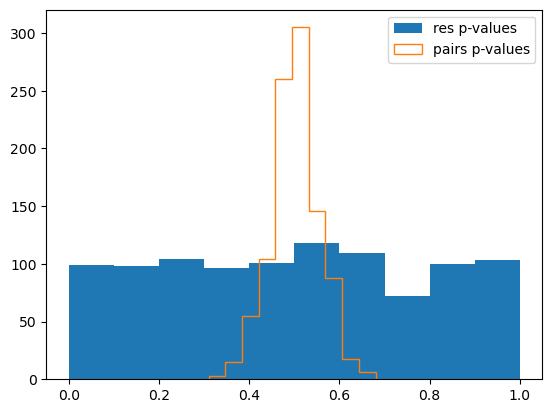

In [18]:
plt.hist(bootstraps_res_p_values, label="res p-values")
plt.hist(bootstraps_pairs_p_values, histtype="step", label="pairs p-values")
plt.legend()
plt.show()

In [28]:
ci95_res_pval = np.percentile(bootstraps_res_p_values, [2.5, 97.5])
ci95_pairs_pval = np.percentile(bootstraps_pairs_p_values, [2.5, 97.5])

print(ci95_res_pval)
print(ci95_pairs_pval)

[0.02 0.98]
[0.39975 0.6    ]


In [32]:
low_level_res, high_level_res = ci95_res_pval
ci95_res_corrected = np.percentile(bootstraps_res_bias_corrected_estimates, [low_level_res*100, high_level_res*100])

low_level_pairs, high_level_pairs = ci95_pairs_pval
ci95_pairs_corrected = np.percentile(bootstraps_pairs_bias_corrected_estimates, [low_level_pairs*100, high_level_pairs*100])

print(ci95_res_corrected)
print(ci95_pairs_corrected)

[147.144484   152.04557482]
[149.07055895 151.09626165]
